<a href="https://colab.research.google.com/github/Davemtz192/devops-aws-fase1/blob/main/Actividad_3_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dimensiones del dataset: (1500, 10)


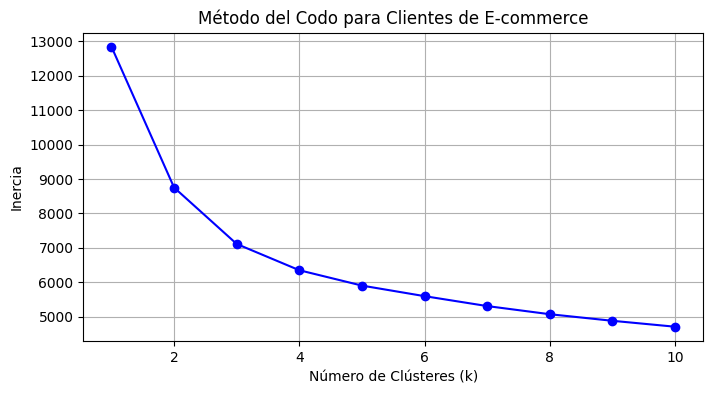


--- Perfiles Promedio por Clúster ---
              Edad  Gasto_Mensual_MXN  Compras_Mensuales  Visitas_Mensuales  \
Cluster                                                                       
0        41.468468        6475.522655           8.210210          23.714715   
1        29.040000         854.203818           1.760000           6.151111   
2        35.142857        2848.673728           5.111111          16.464853   
3        30.926108        2060.293685           4.251232          19.699507   

         Ticket_Promedio_MXN  
Cluster                       
0                 815.755676  
1                 555.878667  
2                 608.150499  
3                 539.857783  


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = pd.read_csv("clientes_clustering.csv")
print("Dimensiones del dataset:", df.shape)

# 2. Preprocesamiento: Limpiar valores nulos y seleccionar variables numéricas
# Excluimos 'Cliente_ID' por ser un identificador único
X = df.drop(columns=["Cliente_ID"]).dropna()

# 3. Normalizar los datos (esencial para K-Means para que todas las variables tengan el mismo peso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Método del Codo para encontrar el número óptimo de clústeres (k)
inertia = []
K = range(1, 11)
for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# Gráfica del codo
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker="o", linestyle="-", color="b")
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Clientes de E-commerce")
plt.grid(True)
plt.show()

# 5. Aplicar K-Means con el k óptimo (por ejemplo, k = 4 basado en el comportamiento típico)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean = df.dropna().copy()
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

# 6. Ver el resumen promedio por segmento de clientes
cluster_summary = df_clean.groupby("Cluster").mean(numeric_only=True)
print("\n--- Perfiles Promedio por Clúster ---")
print(cluster_summary[[  # Mostramos variables clave
    "Edad",
    "Gasto_Mensual_MXN",
    "Compras_Mensuales",
    "Visitas_Mensuales",
    "Ticket_Promedio_MXN",
]])

In [3]:
import pandas as pd

# 1. Cargar el dataset
df = pd.read_csv("clientes_clustering.csv")

# 2. Primeros registros
print("--- Primeros registros ---")
print(df.head())

# 3. Dimensiones del dataset
print("\n--- Dimensiones del dataset ---")
print(df.shape)

# 4. Nombres de columnas y tipos de datos
print("\n--- Tipos de datos ---")
print(df.dtypes)

# 5. Estadísticas descriptivas
print("\n--- Estadísticas descriptivas ---")
print(df.describe())

# 6. Valores faltantes (nulos)
print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum())

# 7. Registros duplicados
print("\n--- Total de registros duplicados ---")
print(df.duplicated().sum())

--- Primeros registros ---
  Cliente_ID  Edad  Antiguedad_Meses  Compras_Mensuales  Gasto_Mensual_MXN  \
0    CLI0001  45.0              32.0                  6            4384.45   
1    CLI0002  28.0              30.0                  6            2916.86   
2    CLI0003  32.0              45.0                  4            3086.35   
3    CLI0004  39.0              31.0                  2             601.29   
4    CLI0005  35.0              17.0                  2            1025.27   

   Visitas_Mensuales  Descuento_Promedio_Pct  Devoluciones_6M  \
0               21.0                    10.0                0   
1               26.0                    15.6                0   
2               12.0                    14.3                2   
3               12.0                    23.3                0   
4                7.0                     9.7                0   

   Dias_Ultima_Compra  Ticket_Promedio_MXN  
0                  24               759.43  
1                   2  

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = pd.read_csv("clientes_clustering.csv")

# 2. Selección de características (excluyendo 'Cliente_ID' por ser solo un identificador)
X = df.drop(columns=["Cliente_ID"])

# 3. Tratamiento de valores faltantes (imputación usando la mediana para evitar sesgos por outliers)
X_imputed = X.fillna(X.median())

# 4. Escalamiento de características (StandardScaler: media 0 y desviación estándar 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Convertir el resultado escalado a DataFrame para visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Dimensiones del dataset procesado:", X_scaled_df.shape)
print("Valores nulos restantes:", X_scaled_df.isnull().sum().sum())
print("\nPrimeros registros escalados:")
print(X_scaled_df.head(3))

Dimensiones del dataset procesado: (1500, 9)
Valores nulos restantes: 0

Primeros registros escalados:
       Edad  Antiguedad_Meses  Compras_Mensuales  Gasto_Mensual_MXN  \
0  1.145988          0.141034           0.489903           0.621324   
1 -0.638604          0.026123           0.489903          -0.018517   
2 -0.218700          0.887955          -0.239481           0.055377   

   Visitas_Mensuales  Descuento_Promedio_Pct  Devoluciones_6M  \
0           0.658945               -0.611924        -0.956791   
1           1.248551               -0.037989        -0.956791   
2          -0.402348               -0.171224         0.882013   

   Dias_Ultima_Compra  Ticket_Promedio_MXN  
0            0.242180             0.409475  
1           -1.026179            -0.700717  
2           -0.680263             0.398258  


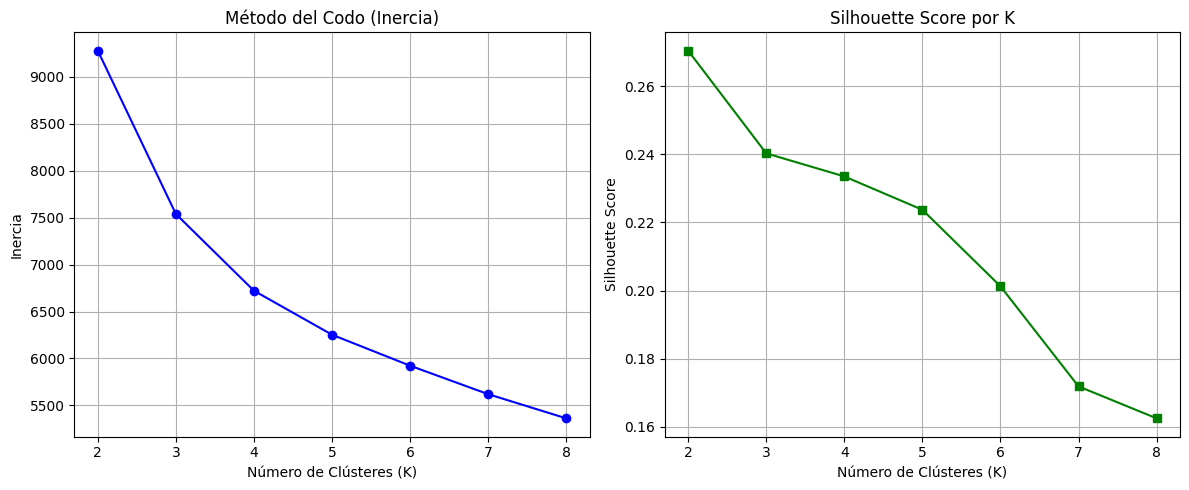

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in K_values:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfica del Método del Codo (Inercia)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_values, inertias, marker='o', color='b')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.grid(True)

# Gráfica de Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_values, silhouette_scores, marker='s', color='g')
plt.title('Silhouette Score por K')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Entrenar K-Means con K = 3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# Asignar los clústeres de vuelta al DataFrame original
df_clusters = df.copy()
df_clusters['Cluster'] = kmeans_final.labels_

# Calcular la media de las variables numéricas por cada clúster para caracterizarlos
perfiles = df_clusters.drop(columns=['Cliente_ID']).groupby('Cluster').mean()
print('--- Perfil promedio por Clúster ---')
print(perfiles)

# Conteo de clientes por clúster
print('\n--- Cantidad de clientes por Clúster ---')
print(df_clusters['Cluster'].value_counts())

--- Perfil promedio por Clúster ---
              Edad  Antiguedad_Meses  Compras_Mensuales  Gasto_Mensual_MXN  \
Cluster                                                                      
0        41.500000         48.675141           8.140449        6404.620603   
1        29.046122         13.575949           1.751046         864.284932   
2        33.768293         30.794521           4.879880        2620.232229   

         Visitas_Mensuales  Descuento_Promedio_Pct  Devoluciones_6M  \
Cluster                                                               
0                23.570621                7.245869         1.171348   
1                 6.204641               17.622152         0.487448   
2                17.668189               19.462576         1.367868   

         Dias_Ultima_Compra  Ticket_Promedio_MXN  
Cluster                                           
0                  6.134831           816.517697  
1                 37.922594           566.260544  
2            

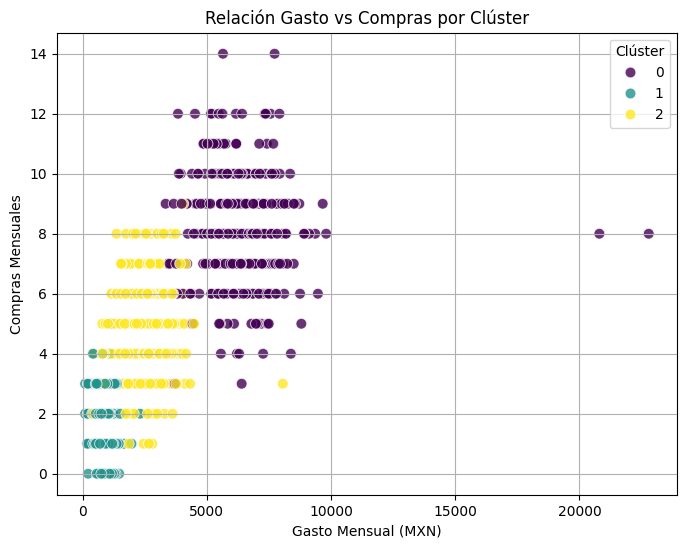

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfica de dispersión: Gasto Mensual vs Compras Mensuales por Clúster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clusters,
    x='Gasto_Mensual_MXN',
    y='Compras_Mensuales',
    hue='Cluster',
    palette='viridis',
    s=60,
    alpha=0.8,
)
plt.title('Relación Gasto vs Compras por Clúster')
plt.xlabel('Gasto Mensual (MXN)')
plt.ylabel('Compras Mensuales')
plt.grid(True)
plt.legend(title='Clúster')
plt.show()

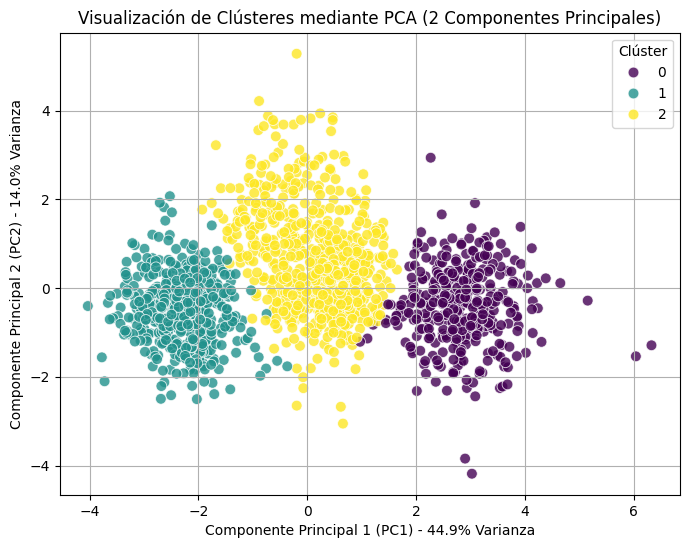

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurarnos de que la columna 'Cluster' esté presente en el DataFrame
df['Cluster'] = kmeans_final.labels_

# 2. Aplicar PCA para reducir a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Crear el DataFrame para la gráfica
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# 4. Generar la gráfica
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=60,
    alpha=0.8,
)
plt.title(
    'Visualización de Clústeres mediante PCA (2 Componentes Principales)'
)
plt.xlabel(
    f'Componente Principal 1 (PC1) - {pca.explained_variance_ratio_[0]*100:.1f}%'
    ' Varianza'
)
plt.ylabel(
    f'Componente Principal 2 (PC2) - {pca.explained_variance_ratio_[1]*100:.1f}%'
    ' Varianza'
)
plt.grid(True)
plt.legend(title='Clúster')
plt.show()

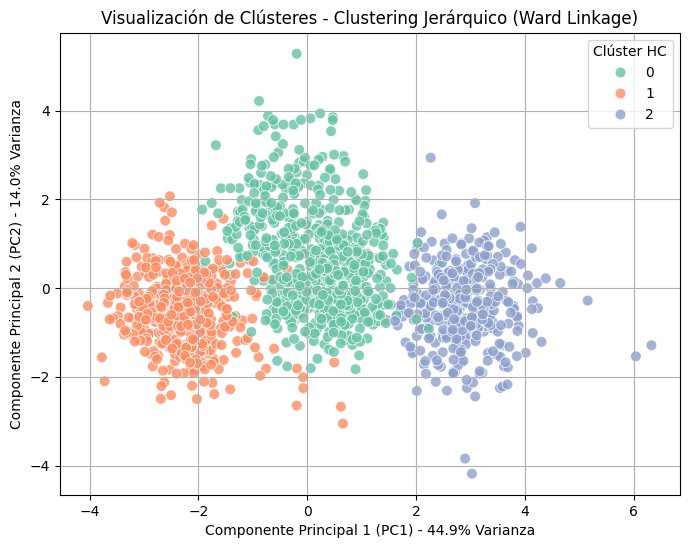

In [10]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aplicar Clustering Jerárquico con 3 clústeres
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)

# 2. Generar gráfica comparativa en el espacio PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue=df['Cluster_HC'],
    palette='Set2',
    s=60,
    alpha=0.8,
)
plt.title(
    'Visualización de Clústeres - Clustering Jerárquico (Ward Linkage)'
)
plt.xlabel(
    f'Componente Principal 1 (PC1) - {pca.explained_variance_ratio_[0]*100:.1f}%'
    ' Varianza'
)
plt.ylabel(
    f'Componente Principal 2 (PC2) - {pca.explained_variance_ratio_[1]*100:.1f}%'
    ' Varianza'
)
plt.grid(True)
plt.legend(title='Clúster HC')
plt.show()